# RTX 4090 MoE operator scaling

This notebook runs the router and fused-MoE scans through a crash-isolated runner. Each shape gets a fresh CUDA process, so an OOM or kernel failure is retained as one failed case instead of corrupting the notebook kernel.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
if ROOT.name == 'tests':
    ROOT = ROOT.parent
if str(ROOT / 'tests') not in sys.path:
    sys.path.insert(0, str(ROOT / 'tests'))
from moe_operator_bench_runner import MoeOperatorBenchmark

benchmark = MoeOperatorBenchmark(
    output_dir='artifacts/operator_benchmark/rtx4090_24gb',
    warmup_ms=50,
    rep_ms=200,
    case_timeout_seconds=1200,
)
benchmark.preflight()

{'python': '/home/ubuntu/mini-train-sys/.venv/bin/python',
 'torch': '2.5.1+cu118',
 'torch_cuda': '11.8',
 'gpu': 'NVIDIA GeForce RTX 4090',
 'compute_capability': '8.9',
 'memory_gib': 23.64971923828125,
 'profiles': {'project_formal': {'name': 'project_formal',
   'num_experts': 8,
   'hidden': 768,
   'intermediate': 1024,
   'top_k': 2,
   'token_sizes': (512, 2048, 8192, 32768, 57344)},
  'mixtral_7b': {'name': 'mixtral_7b',
   'num_experts': 8,
   'hidden': 4096,
   'intermediate': 14336,
   'top_k': 2,
   'token_sizes': (16, 64, 256)}},
 'router_sizes': (1024, 4096, 16384, 65536, 262144)}

## Full scan

`project_formal` reaches the real 112 × 512 local-token workload. `mixtral_7b` preserves the prior 4096/14336 industrial reference shape while keeping correctness and gradient copies inside 24 GB.

In [2]:
summary = benchmark.run()
{
    'quality_gate_passed': summary['quality_gate_passed'],
    'completed_rows': len(summary['rows']),
    'case_failures': len(summary['case_failures']),
    'correctness_failures': len(summary['correctness_failures']),
    'output_dir': summary['output_dir'],
}

{'quality_gate_passed': False,
 'completed_rows': 26,
 'case_failures': 0,
 'correctness_failures': 6,
 'output_dir': '/data/mini-train-sys/artifacts/operator_benchmark/rtx4090_24gb'}

,kernel,provider,size,size_label,status,fwd_correct,fwd_max_abs,fwd_max_rel,bwd_correct,bwd_max_abs,...,full_p50_ms,full_p95_ms,full_peak_mem_mb,bwd_p50_ms,bwd_p95_ms,bwd_peak_mem_mb,fwd_speedup,bwd_speedup,full_speedup,profile
0,router_postprocess,torch,1024,"tokens; E=8, K=2",ok,True,0.000000e+00,0.000000e+00,True,0.000000e+00,...,1.561600,1.907866,0.180664,1.065984,1.214288,0.066895,1.000000,1.000000,1.000000,default
1,router_postprocess,triton,1024,"tokens; E=8, K=2",ok,True,9.536743e-07,5.283384e-07,True,3.576279e-07,...,0.763872,0.843981,0.065430,0.624112,0.759245,0.048340,5.750724,1.708001,2.044321,default
2,router_postprocess,torch,4096,"tokens; E=8, K=2",ok,True,0.000000e+00,0.000000e+00,True,0.000000e+00,...,1.545216,1.974298,0.719727,1.083456,1.110835,0.266113,1.000000,1.000000,1.000000,default
3,router_postprocess,triton,4096,"tokens; E=8, K=2",ok,True,2.384186e-07,5.283384e-07,True,3.874302e-07,...,0.786432,0.926926,0.252930,0.669696,0.784427,0.188965,6.666666,1.617833,1.964844,default
4,router_postprocess,torch,16384,"tokens; E=8, K=2",ok,True,0.000000e+00,0.000000e+00,True,0.000000e+00,...,1.503232,1.952776,2.875977,1.057792,1.180371,1.062988,1.000000,1.000000,1.000000,default
5,router_postprocess,triton,16384,"tokens; E=8, K=2",ok,True,9.536743e-07,1.072082e-06,True,4.172325e-07,...,1.001568,1.143808,1.002930,0.640400,0.778350,0.751465,5.588235,1.651768,1.500879,default
6,router_postprocess,torch,65536,"tokens; E=8, K=2",ok,True,0.000000e+00,0.000000e+00,True,0.000000e+00,...,1.520640,1.957990,11.500977,1.044480,1.210747,4.250488,1.000000,1.000000,1.000000,default
7,router_postprocess,triton,65536,"tokens; E=8, K=2",ok,True,3.337860e-06,1.897616e-06,True,4.768372e-07,...,0.772688,0.817254,4.002930,0.623728,0.770304,3.001465,5.595238,1.674576,1.967987,default
8,router_postprocess,torch,262144,"tokens; E=8, K=2",ok,True,0.000000e+00,0.000000e+00,True,0.000000e+00,...,0.864256,0.886635,46.000977,0.613376,0.636058,17.000488,1.000000,1.000000,1.000000,default
9,router_postprocess,triton,262144,"tokens; E=8, K=2",ok,True,1.859665e-05,4.039990e-06,True,5.888287e-07,...,0.403552,0.426035,16.002930,0.379296,0.403558,12.001465,4.928223,1.617143,2.141622,default


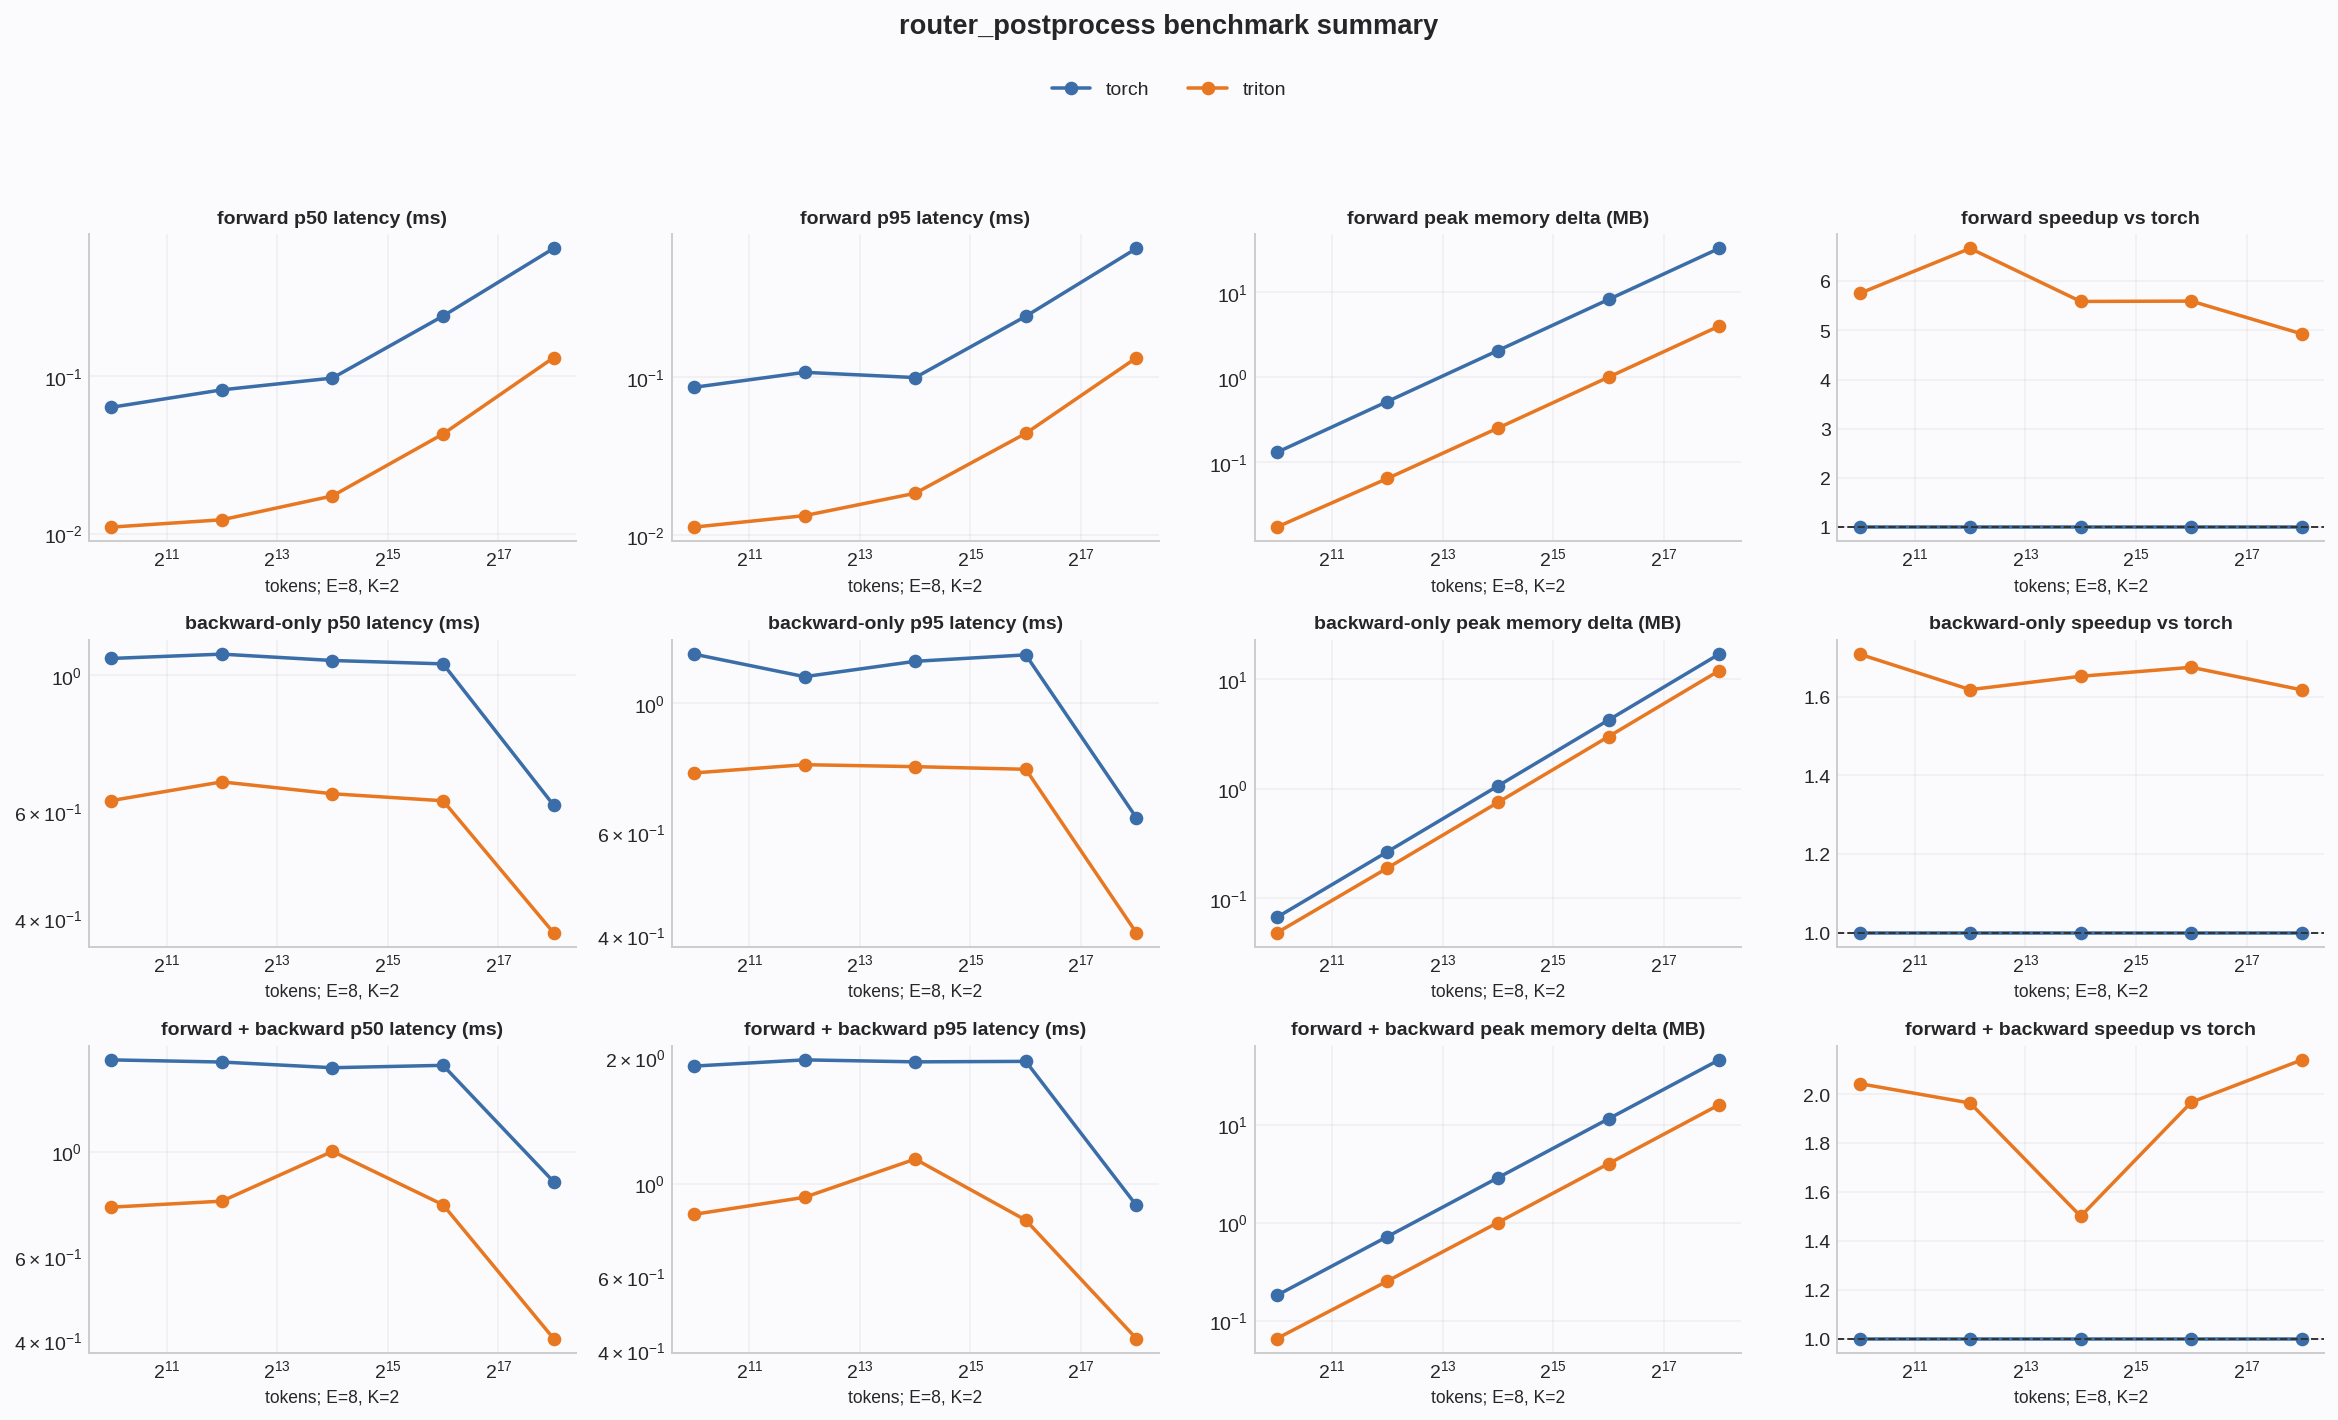

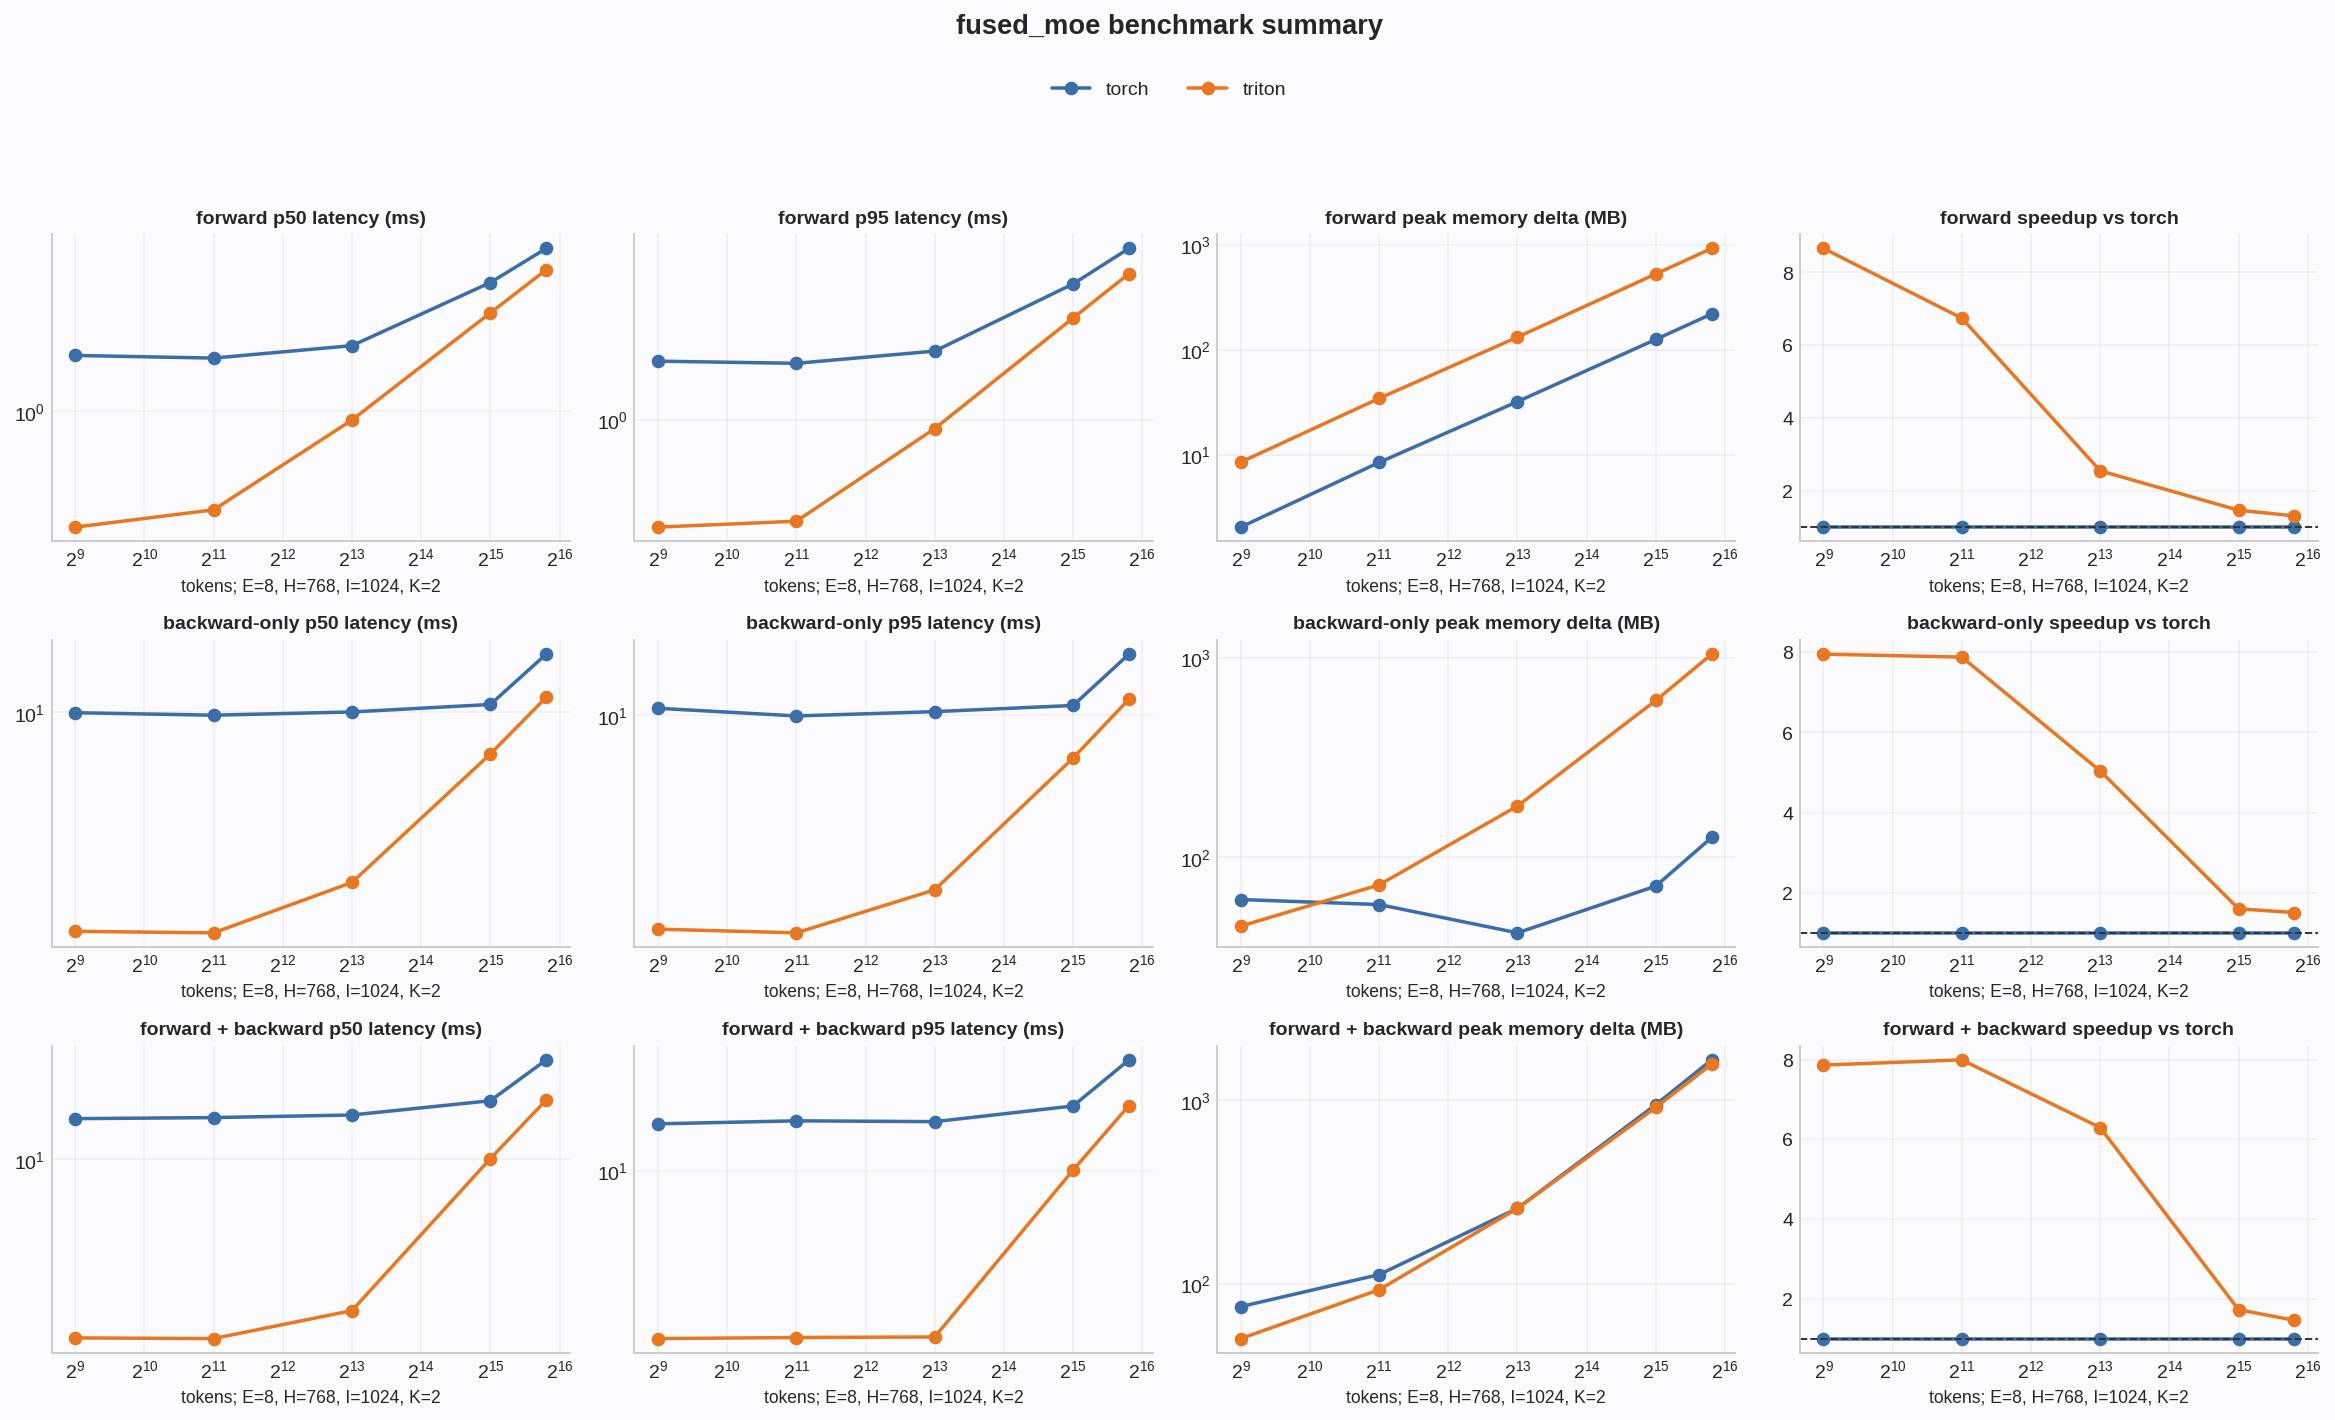

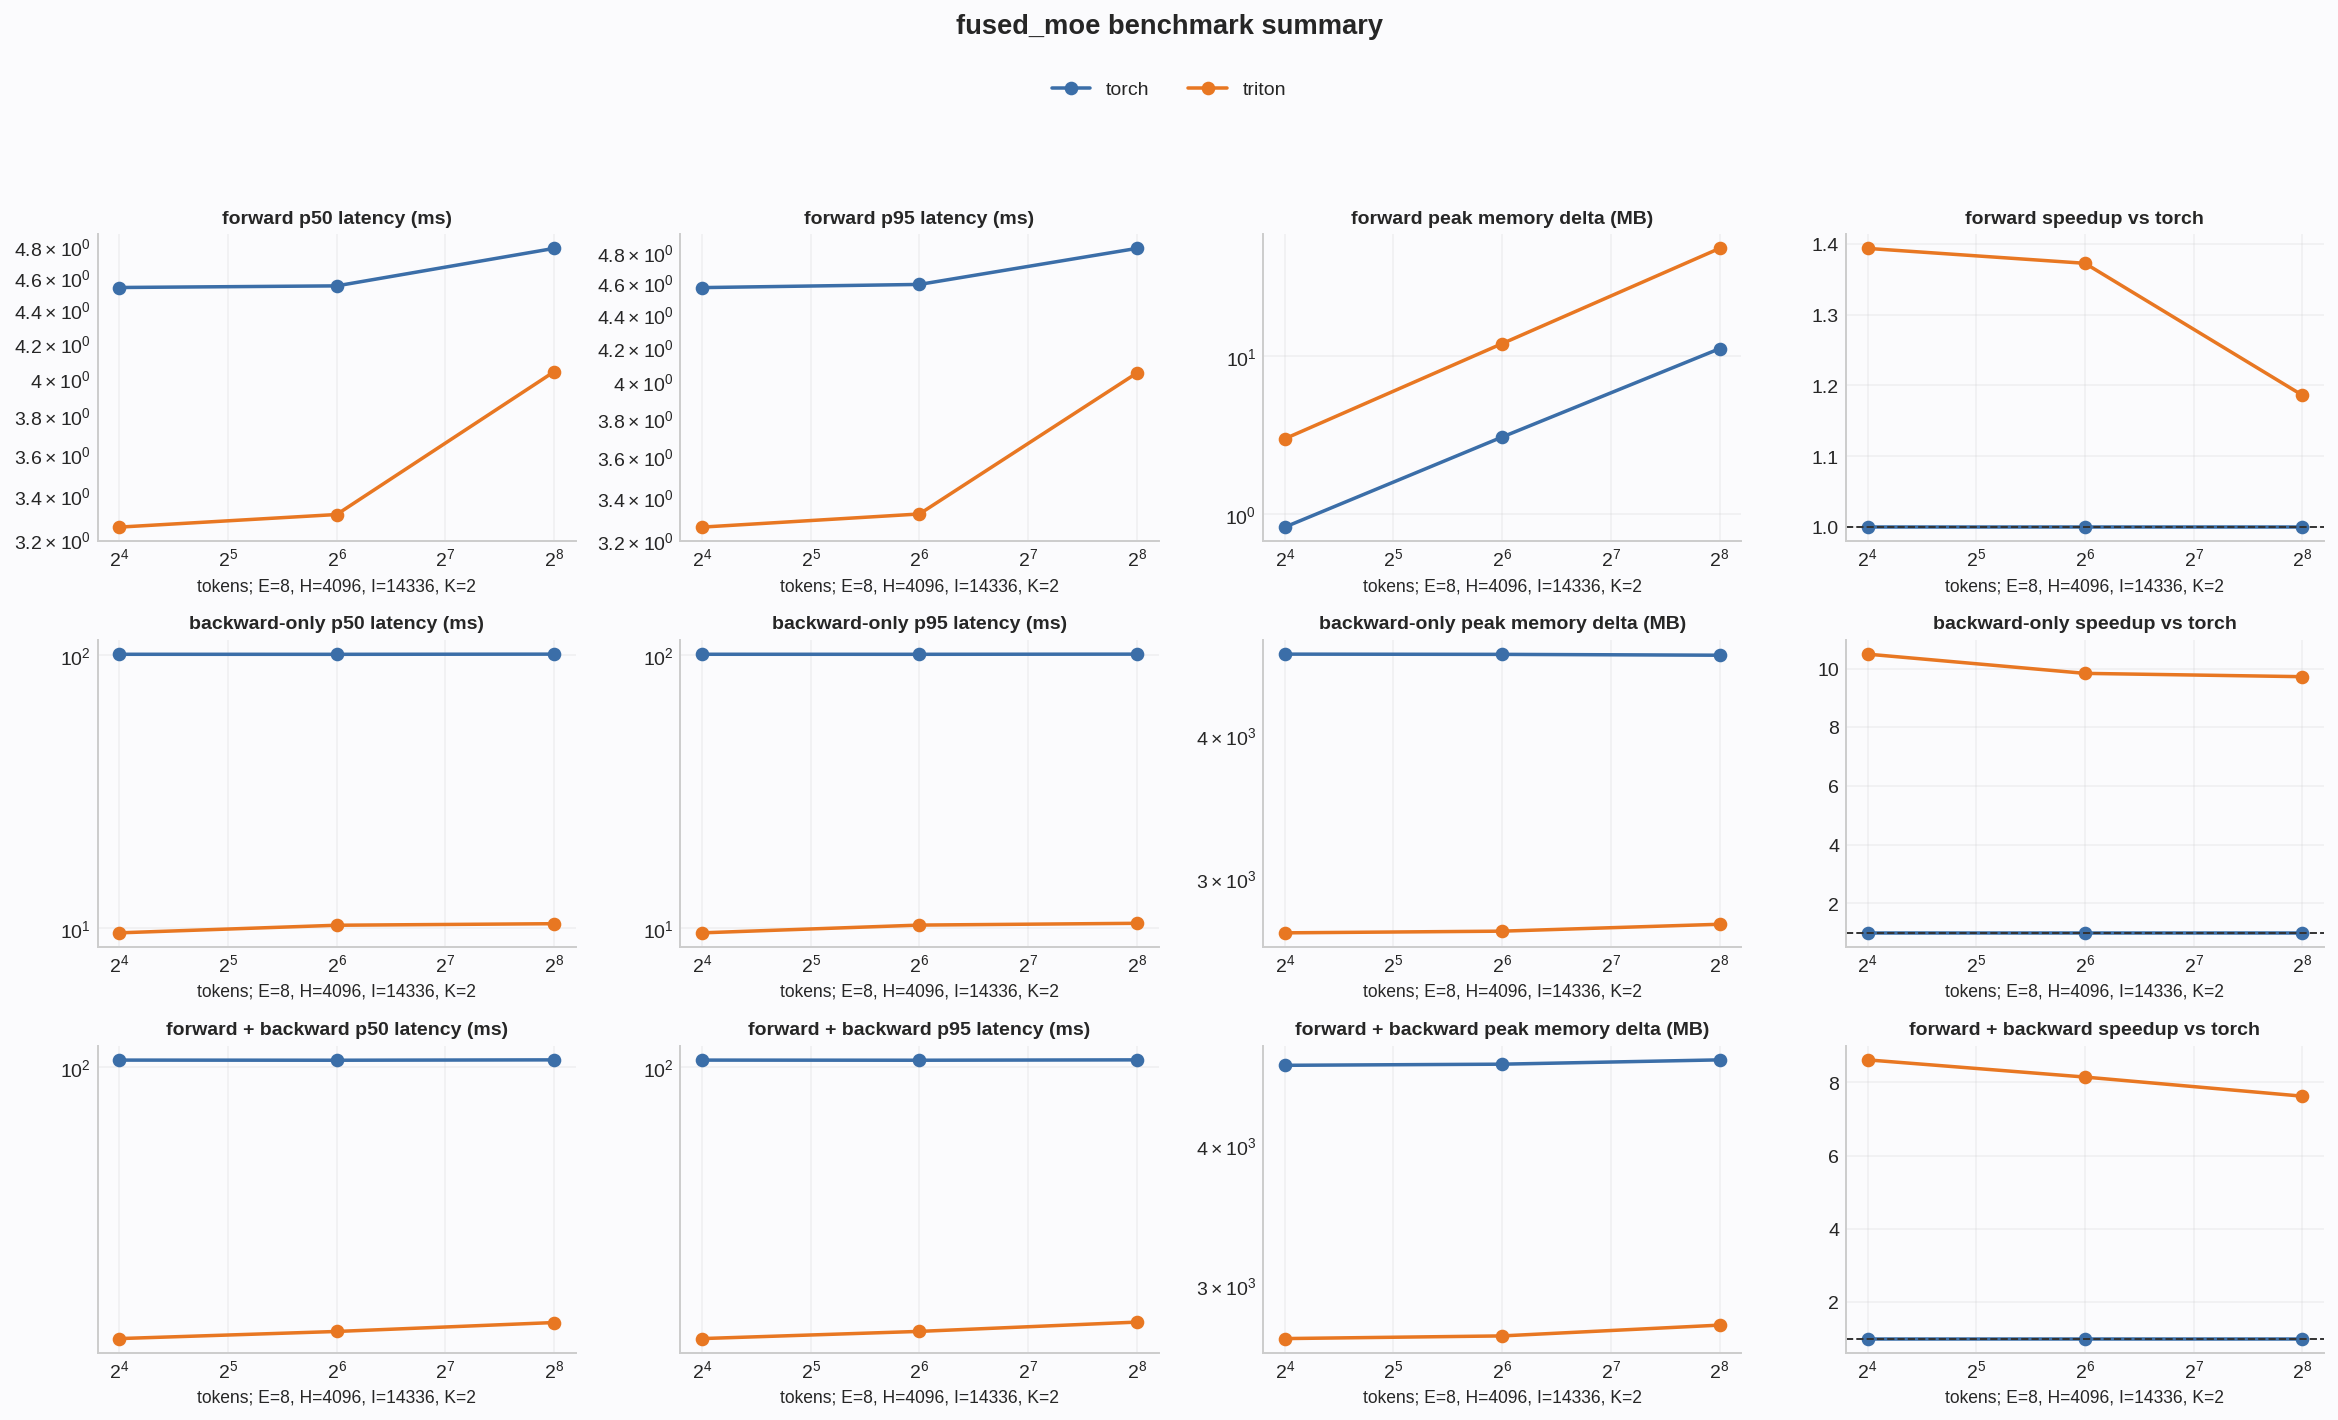

In [3]:
benchmark.display(summary)